In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import cv2
import sklearn as sk

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/monkeytype/mt_dataset_catm.csv')
df = df[df['participant_id']=='Feliks']

X = df.drop(columns=['chosen_local_cls', 'participant_id','time_reaction_task','time_reaction_mean'
])   # признаки
y = df['chosen_local_cls']                  # целевая переменная
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1350 entries, 1687 to 3036
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brightness0           1350 non-null   float64
 1   brightness1           1350 non-null   float64
 2   brightness2           1350 non-null   float64
 3   brightness3           1350 non-null   float64
 4   local_symbol_cls0     1350 non-null   object 
 5   local_symbol_cls1     1350 non-null   object 
 6   local_symbol_cls2     1350 non-null   object 
 7   local_symbol_cls3     1350 non-null   object 
 8   correct_symbol_cls    1350 non-null   object 
 9   correct_local_cls     1350 non-null   int64  
 10  participant_linspace  1350 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 126.6+ KB


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 20% — тест
    random_state=0,      # фиксируем для воспроизводимости
    stratify=y            # важно для логистической регрессии!
)


In [ ]:
X_test_sorted = X_test.sort_values(by="participant_linspace")

# перестраиваем y_test в той же последовательности
y_test_sorted = y_test.loc[X_test_sorted.index]

In [ ]:
#from sklearn.linear_model import LogisticRegression

#model = LogisticRegression(max_iter=10000, solver='saga', class_weight='balanced')
#model.fit(X_train, y_train)

#coefs = model.coef_
#intercepts = model.intercept_
#classes = model.classes_
#from sklearn.metrics import accuracy_score, classification_report
#y_pred = model.predict(X_test)
#print("Accuracy:", accuracy_score(y_test, y_pred))
#print(classification_report(y_test, y_pred))

#df_coefs = pd.DataFrame(coefs.T, index=X.columns, columns=[f"coef_class_{c}" for c in classes])
#df_coefs
#import itertools, numpy as np
#pairs = {}
#for i,j in itertools.combinations(range(len(classes)), 2):
#    diff = coefs[i] - coefs[j]         # вектор по признакам
#    pairs[f"{classes[i]}_vs_{classes[j]}"] = diff

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np

# ----- 3. Preprocessing -----
# Определим кои признаки числовые, а кои категориальные
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    # RandomForest не требует масштабирования, поэтому пропускаем StandardScaler
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
], remainder='drop')

# ----- 4. Собираем Pipeline с моделем -----
rf = RandomForestClassifier(n_estimators=120,
                            random_state=0,
                            n_jobs=-1,
                            oob_score=True,
                            class_weight=None,
                            min_samples_leaf=2,
                            min_samples_split=7,
                            max_depth=15
)
pipeline = ImbPipeline([
    ('preproc', preprocessor),
    ('smote', SMOTE(random_state=0, k_neighbors=3,)), #sampling_strategy='not majority
    ('rf', rf)
])

# ----- 5. Обучаем -----
pipeline.fit(X_train, y_train)

# ----- 6. Оценка -----
y_pred = pipeline.predict(X_test)
y_pred_tr = pipeline.predict(X_train)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("Accuracy on training:", accuracy_score(y_train, y_pred_tr))
print(classification_report(y_train, y_pred_tr))
#print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# OOB score (если интересует)
rf_trained = pipeline.named_steps['rf']
if hasattr(rf_trained, 'oob_score_'):
    print("OOB score:", rf_trained.oob_score_)

# ----- 7. Важность признаков -----
importances = rf_trained.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf_trained.estimators_], axis=0)
# сортируем и показываем топ
preproc = pipeline.named_steps['preproc']
# имена числовых
feature_names = []
feature_names += num_cols
# имена OHE-категорий
if cat_cols:
    ohe = preproc.named_transformers_['cat'].named_steps['ohe']
    ohe_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names += ohe_feature_names

idx_sorted = np.argsort(importances)[::-1]
top_n = len(feature_names)
print("Top features:", top_n )
for i in idx_sorted[:top_n]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

#result = permutation_importance(
#    rf_trained, X_test, y_test, n_repeats=10, random_state=0, n_jobs=-1
#)

forest_importances = pd.Series(importances, index=feature_names)
#forest_importances = pd.Series(result.importances_mean, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

KeyboardInterrupt: 

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


[0.9090909090909091, 0.7272727272727273, 0.7272727272727273, 0.6363636363636364, 0.6363636363636364, 0.5454545454545454, 0.5454545454545454, 0.8181818181818182, 0.6363636363636364, 0.6363636363636364, 0.5454545454545454, 0.6363636363636364, 0.36363636363636365, 0.6363636363636364, 0.5454545454545454, 0.5454545454545454, 0.9090909090909091, 0.36363636363636365, 0.8181818181818182, 0.7272727272727273, 0.6363636363636364, 0.5454545454545454, 0.8181818181818182, 0.9090909090909091, 0.6363636363636364, 0.9090909090909091, 0.6363636363636364, 0.7272727272727273, 0.4, 0.7]


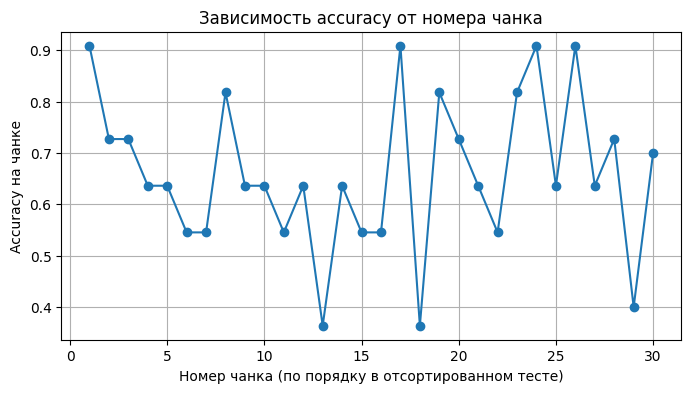

In [ ]:
n_chunks = 30

X_chunks = np.array_split(X_test_sorted, n_chunks)
y_chunks = np.array_split(y_test_sorted, n_chunks)

chunk_accuracies = []
for X_part, y_part in zip(X_chunks, y_chunks):
    y_pred_part = pipeline.predict(X_part)
    acc = accuracy_score(y_part, y_pred_part)
    chunk_accuracies.append(acc)

print(chunk_accuracies)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(chunk_accuracies) + 1), chunk_accuracies, marker='o')
plt.xlabel("Номер чанка (по порядку в отсортированном тесте)")
plt.ylabel("Accuracy на чанке")
plt.title("Зависимость accuracy от номера чанка")
plt.grid(True)
plt.show()

In [ ]:
majority_class = y_train.value_counts().idxmax()
y_pred_static = np.repeat(majority_class, len(y_test))
print("Accuracy of static classifier:", accuracy_score(y_test, y_pred_static))
print(classification_report(y_test, y_pred_static))

Accuracy of static classifier: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.00      0.00      0.00       140
           2       0.50      1.00      0.67       164
           3       0.00      0.00      0.00         7

    accuracy                           0.50       328
   macro avg       0.12      0.25      0.17       328
weighted avg       0.25      0.50      0.33       328



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#from sklearn.model_selection import RandomizedSearchCV
#from scipy.stats import randint

# ----- 5. Обучение с RandomizedSearchCV -----

# Сетка/распределения гиперпараметров для случайного леса
#param_distributions = {
#    'rf__n_estimators': randint(100, 400),       # число деревьев
#    'rf__max_depth': randint(3, 20),             # максимальная глубина
#    'rf__min_samples_split': randint(2, 20),     # мин. объектов для сплита
#    'rf__min_samples_leaf': randint(1, 20),      # мин. объектов в листе
#    'rf__max_features': ['sqrt', 'log2', 0.2],   # сколько признаков смотреть
#    'rf__class_weight': [None, 'balanced', 'balanced_subsample']
#}

#rf_random_search = RandomizedSearchCV(
#    estimator=pipeline,
#    param_distributions=param_distributions,
#    n_iter=1000,                # сколько комбинаций попробовать
#    scoring='f1_micro',       # метрика оптимизации
#    cv=5,                     # k-fold CV
#    verbose=1,
#    n_jobs=-1,
#    random_state=0
#)

#rf_random_search.fit(X_train, y_train)

#print("Лучшие параметры:", rf_random_search.best_params_)
#print("Лучший scoring:", rf_random_search.best_score_)

In [ ]:
import shap
X_train_transformed = preproc.transform(X_train)

# Если матрица разреженная – делаем плотной (shap иногда этого требует)
if hasattr(X_train_transformed, "toarray"):
    X_train_dense = X_train_transformed.toarray()
else:
    X_train_dense = X_train_transformed

# 8.2. Строим TreeExplainer для случайного леса
explainer = shap.TreeExplainer(rf_trained)

# Для классификации shap_values – список массивов по классам
shap_values = explainer.shap_values(X_train_dense)
print(shap_values.shape)
print(X_train_dense.shape)

(1310, 36, 4)
(1310, 36)


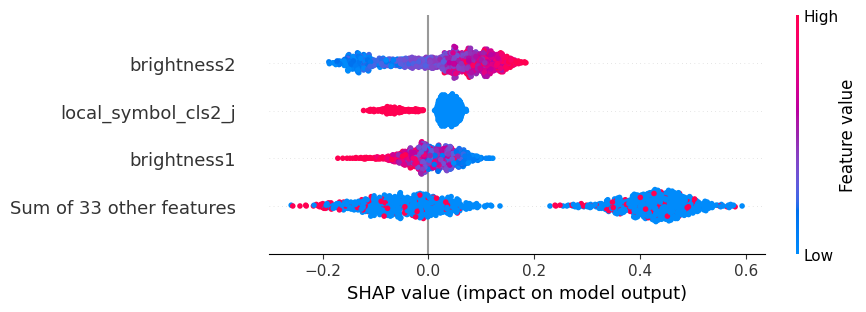

In [ ]:
# 8.3. Глобальная важность признаков
#shap.initjs()
shap_exp = shap.Explanation(
    values=shap_values[:,:,2],
    data=X_train_dense,
    feature_names=feature_names
)
shap.plots.beeswarm(shap_exp, max_display=4)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

num_pipe = SkPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Важно: OneHotEncoder → плотная матрица, чтобы SMOTE работал
cat_pipe = SkPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # если sklearn >= 1.2:
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
    ],
    remainder='drop'
)

smote = SMOTE(
    sampling_strategy={0: 250, 3: 250},  # oверсэмплим все классы, кроме самого частого
    k_neighbors=3,
    random_state=0
)

lgbm = LGBMClassifier(
    objective='multiclass',
    random_state=0,
    n_jobs=-1,
    #class_weight='balanced',  # можно попробовать и так, но с SMOTE обычно не нужно
    learning_rate=0.19,
    min_child_samples=79,
    num_leaves=60,
    max_depth=2,
    reg_lambda=0.5,
)
pipeline = ImbPipeline(steps=[
    ('preproc', preprocessor),
    ('smote', smote),
    ('lgbm', lgbm)
])

#param_distributions = {
#    'lgbm__n_estimators': randint(100, 600),
#    'lgbm__num_leaves': randint(20, 80),
#    'lgbm__max_depth': randint(-1, 20),        # -1 = без ограничения
#    'lgbm__learning_rate': uniform(0.01, 0.2), # от 0.01 до 0.21
#    'lgbm__min_child_samples': randint(10, 100),
#    'lgbm__subsample': uniform(0.6, 0.4),      # [0.6, 1.0]
#    'lgbm__colsample_bytree': uniform(0.6, 0.4)
#}

#search = RandomizedSearchCV(
#    estimator=pipeline,
#    param_distributions=param_distributions,
#    n_iter=50,               # можно увеличить до 80–100, если есть время
#    cv=5,
#    scoring='f1_macro',      # важный момент: оптимизируем макро-F1
#    n_jobs=-1,
#    verbose=1,
#    random_state=0
#)

#search.fit(X_train, y_train)

#print("Лучшие параметры:", search.best_params_)
#print("Лучший scoring:", search.best_score_)
pipeline.fit(X_train, y_train)

best_pipeline = pipeline #search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000647 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3190
[LightGBM] [Info] Number of data points in the train set: 1715, number of used features: 38
[LightGBM] [Info] Start training from score -1.925707
[LightGBM] [Info] Start training from score -1.119232
[LightGBM] [Info] Start training from score -0.962533
[LightGBM] [Info] Start training from score -1.925707
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
y_pred_tr = best_pipeline.predict(X_train)

print("Train accuracy:", accuracy_score(y_train, y_pred_tr))
print("Train classification report:")
print(classification_report(y_train, y_pred_tr))

Train accuracy: 0.7923664122137405
Train classification report:
              precision    recall  f1-score   support

           0       0.87      0.39      0.54        69
           1       0.79      0.78      0.78       560
           2       0.79      0.86      0.83       655
           3       0.92      0.42      0.58        26

    accuracy                           0.79      1310
   macro avg       0.84      0.61      0.68      1310
weighted avg       0.80      0.79      0.79      1310



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
preproc = best_pipeline.named_steps['preproc']
lgbm_model = best_pipeline.named_steps['lgbm']
X_explain = X_train  # или X_test

X_explain_tr = preproc.transform(X_explain)

# Если вдруг вернётся разреженная матрица — делаем плотной
if hasattr(X_explain_tr, "toarray"):
    X_explain_tr = X_explain_tr.toarray()

feature_names = []
# числовые
feature_names += num_cols
if cat_cols:
    ohe = preproc.named_transformers_['cat'].named_steps['ohe']
    ohe_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names += ohe_feature_names

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_explain_tr)
print(shap_values.shape)
print(X_explain_tr.shape)

(1310, 38, 4)
(1310, 38)


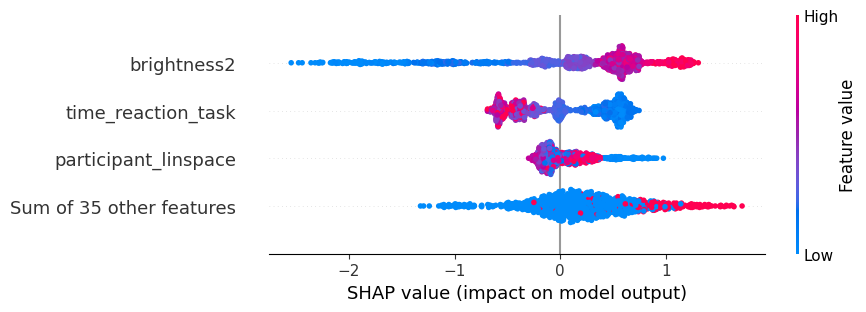

In [ ]:
shap_exp = shap.Explanation(
    values=shap_values[:,:,2],
    data=X_explain_tr,
    feature_names=feature_names
)
shap.plots.beeswarm(shap_exp, max_display=4)

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from category_encoders import TargetEncoder
from lightgbm import LGBMClassifier

# Если хочешь SMOTE в этом пайплайне:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from scipy.stats import randint, uniform

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

num_pipe = SkPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipe = SkPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('te', TargetEncoder(
        handle_unknown='value',
        handle_missing='value',
        smoothing=0.3
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=False  # <-- Имена колонок будут как исходные
)

#Ключевая строка для sklearn >=1.2:
preprocessor.set_output(transform="pandas")

lgbm = LGBMClassifier(
    objective='multiclass',
    random_state=0,
    n_jobs=-1
)

smote = SMOTE(
    sampling_strategy='not majority',  # или словарь {класс: целевой размер}
    k_neighbors=3,
    random_state=0
)

pipeline = ImbPipeline(steps=[
    ('preproc', preprocessor),
    ('smote', smote),
    ('lgbm', lgbm)
])

param_distributions = {
    'lgbm__n_estimators': randint(100, 200),
    'lgbm__num_leaves': randint(20, 80),
    'lgbm__max_depth': randint(2, 10),
    'lgbm__learning_rate': uniform(0.01, 0.08),
    'lgbm__min_child_samples': randint(20, 80),
    'lgbm__subsample': uniform(0.8, 0.2),        # bagging_fraction
    'lgbm__colsample_bytree': uniform(0.8, 0.2), # feature_fraction
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='f1_macro',   # важный момент: не accuracy
    n_jobs=-1,
    verbose=1,
    random_state=0
)

search.fit(X_train, y_train)

print("Лучшие параметры:", search.best_params_)
print("Лучшая f1_macro (CV):", search.best_score_)

best_pipeline = search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000421 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 2740, number of used features: 13
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [ ]:
preproc = best_pipeline.named_steps['preproc']
lgbm_model = best_pipeline.named_steps['lgbm']
X_explain = X_train  # или X_test

X_explain_tr = preproc.transform(X_explain)
print(X_explain_tr.shape)
print(X_explain_tr.head())
# Если вдруг вернётся разреженная матрица — делаем плотной
#if hasattr(X_explain_tr, "toarray"):
#    X_explain_tr = X_explain_tr.toarray()

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_explain_tr)
print(shap_values.shape)
print(X_explain_tr.shape)


(1349, 13)
      brightness0  brightness1  brightness2  brightness3  correct_local_cls  \
407     41.573820    46.377232    42.928093    27.135204                3.0   
858     34.939573    43.445950    58.788026    20.359694                1.0   
1294    70.899872    41.573820    30.128428    33.764429                2.0   
878     28.571588    27.439094    44.271365    35.401706                2.0   
471     27.970982    47.967873    50.815689    32.439892                3.0   

      participant_linspace  time_reaction_task  time_reaction_mean  \
407               0.241400               798.0              1163.0   
858               0.508897               990.0              1368.0   
1294              0.767497              1451.0              1345.0   
878               0.520759              1283.0              1106.0   
471               0.279359               842.0              1008.0   

      local_symbol_cls0  local_symbol_cls1  local_symbol_cls2  \
407            1.203463     

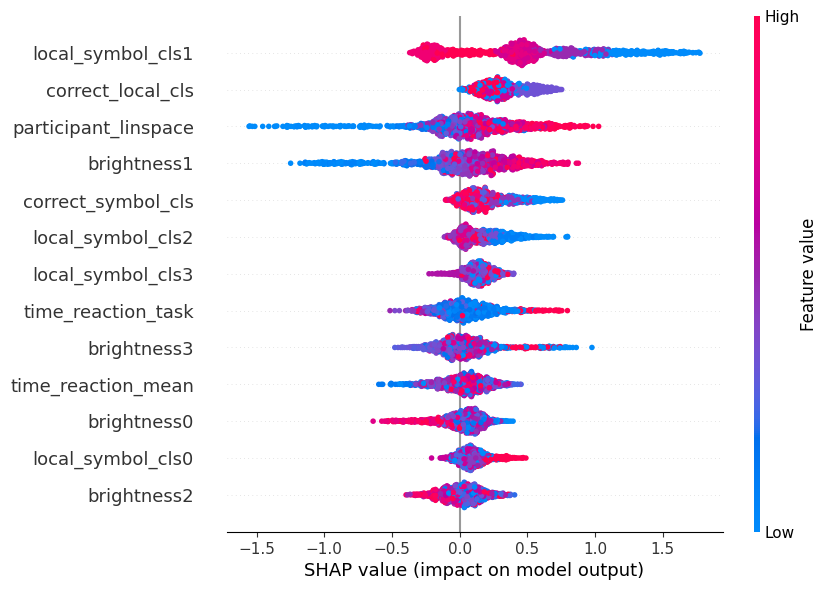

In [ ]:
shap_exp = shap.Explanation(
    values=shap_values[:,:,1],
    data=X_explain_tr.values,
    feature_names=X_explain_tr.columns.tolist()
)
shap.plots.beeswarm(shap_exp, max_display=20)

In [ ]:
preproc = best_pipeline.named_steps['preproc']
te = preproc.named_transformers_['cat'].named_steps['te']

# 2. Смотрим mapping
print(te.mapping)

{0: 0
 1    1.203463
 2    1.319048
 3    1.119048
 4    1.248927
 5    1.219388
 6    1.171806
-1    1.210526
-2    1.210526
dtype: float64, 1: 1
 1    1.240506
 2    1.185022
 3    1.253456
 4    1.223577
 5    1.090517
 6    1.284211
-1    1.210526
-2    1.210526
dtype: float64, 2: 2
 1    1.310811
 2    1.188596
 3    1.216000
 4    1.067265
 5    1.097345
 6    1.405000
-1    1.210526
-2    1.210526
dtype: float64, 3: 3
 1    1.197309
 2    1.316456
 3    1.124444
 4    1.199095
 5    1.190476
 6    1.231132
-1    1.210526
-2    1.210526
dtype: float64, 4: 4
 1    1.144186
 2    1.182573
 3    1.286344
 4    1.088785
 5    1.254808
 6    1.295082
-1    1.210526
-2    1.210526
dtype: float64}
